[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/heitorramos/icd/blob/main/exemplos/15-poder-multiplos/notebook-colab.ipynb)


In [ ]:
# Preparação automática para execução no Google Colab.
# Fora do Colab, esta célula não altera o diretório de trabalho.
try:
    import google.colab  # type: ignore
except ImportError:
    pass
else:
    import os
    import subprocess
    from pathlib import Path

    repository = Path("/content/icd")
    if not repository.exists():
        subprocess.run([
            "git", "clone", "--depth", "1",
            "https://github.com/heitorramos/icd.git", str(repository)
        ], check=True)
    os.chdir(repository / "exemplos/15-poder-multiplos")
    print("Material preparado em:", Path.cwd())


# Poder e múltiplos testes com Cookie Cats

Notebook de estudo da Aula 15

# Objetivos

Este notebook usa um experimento A/B em um jogo móvel para conectar
quatro ideias:

1.  permutação como construção natural da hipótese nula;
2.  bootstrap recentralizado como outra forma de simular $H_0$;
3.  bootstrap usual como construção natural da incerteza sob $H_A$;
4.  poder e múltiplos testes como problemas de planejamento.

## Como estudar este capítulo

Poder e multiplicidade tratam das consequências de repetir decisões
estatísticas. Poder é a probabilidade de detectar um efeito específico
quando ele realmente existe. Ele depende do tamanho do efeito, da
variabilidade, do tamanho amostral, do nível de significância e do
procedimento de teste. Por isso, não existe “o poder do teste” sem
definir uma alternativa.

Quando várias hipóteses são testadas, aumentam as oportunidades de
falsos positivos. Bonferroni e Holm controlam a probabilidade de ao
menos um falso positivo na família (FWER). Benjamini–Hochberg controla a
proporção esperada de falsos positivos entre as descobertas (FDR). Esses
objetivos são diferentes e conduzem a decisões diferentes.

O exemplo Cookie Cats conecta todo o fluxo: usamos permutação para
representar $H_0$, bootstrap usual para representar incerteza próxima à
alternativa observada e simulação para estudar poder. Depois repetimos o
raciocínio para várias métricas. Ao ler as saídas, identifique sempre
qual distribuição está sendo construída e qual erro o procedimento
pretende controlar.

# 1. Download da base

In [ ]:
import kagglehub
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

path = kagglehub.dataset_download("matinmahmoudi/rounds-and-retention")
csv_path = next(Path(path).rglob("*.csv"))
df = pd.read_csv(csv_path)
df.head()

> **Interpretação**
>
> Antes de interpretar resultados, confirme o que cada linha representa,
> o período coberto e as colunas realmente disponíveis. Essa definição
> determina quais agregações e comparações são válidas.

# 2. O que é a base?

Cada linha representa um jogador. A intervenção move a primeira porta
que interrompe o avanço do nível 30 para o nível 40. Os jogadores foram
atribuídos aleatoriamente às versões durante o experimento.

In [ ]:
print(df.shape)
print(df.isna().sum())
print("IDs duplicados:", df["userid"].duplicated().sum())
df.groupby("version").agg(
    jogadores=("userid", "size"),
    rodadas_média=("sum_gamerounds", "mean"),
    rodadas_mediana=("sum_gamerounds", "median"),
    retenção_1=("retention_1", "mean"),
    retenção_7=("retention_7", "mean"),
)

# 3. Análise descritiva

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["version"].value_counts().plot.bar(ax=axes[0])
df.groupby("version")[["retention_1", "retention_7"]].mean().T.plot.bar(ax=axes[1])
axes[0].set_title("Tamanho dos grupos")
axes[1].set_title("Retenção observada")
plt.show()

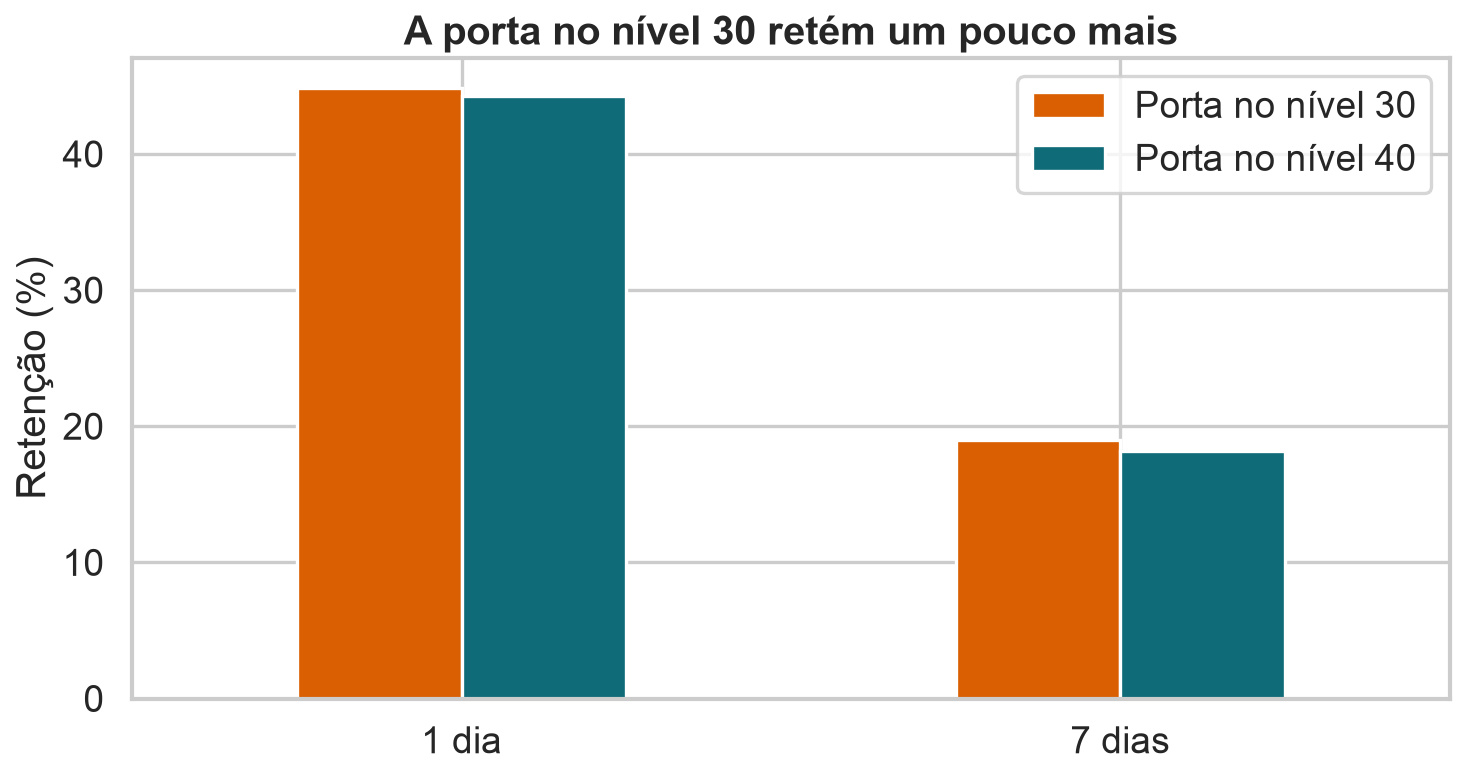

In [ ]:
df["sum_gamerounds"].describe(percentiles=[.50, .90, .95, .99, .999])

> **Interpretação**
>
> Poder depende do efeito, variabilidade, tamanho amostral e nível de
> significância. Ao testar várias hipóteses, defina previamente a
> família e escolha FWER ou FDR conforme o custo dos falsos positivos.

Existe um valor extremo de 49.854 rodadas. Não o remova silenciosamente:
a decisão sobre exclusões deve ser anterior ao teste e acompanhada por
análise de sensibilidade.

# 4. Métrica primária e efeito

Usaremos retenção em 7 dias como métrica primária:

$$
\Delta=p_{30}-p_{40}
$$

In [ ]:
y30 = df.loc[df.version.eq("gate_30"), "retention_7"].astype(float).to_numpy()
y40 = df.loc[df.version.eq("gate_40"), "retention_7"].astype(float).to_numpy()
observed = y30.mean() - y40.mean()
print(f"Diferença observada: {observed:.4%}")

> **Interpretação**
>
> $\widehat\Delta$ mede a diferença de retenção em pontos percentuais
> entre as versões. Seu sinal indica a direção observada, mas seu
> tamanho ainda precisa ser comparado à incerteza amostral e à
> relevância prática.

# 5. $H_0$ por permutação

Sob $H_0$, os rótulos são trocáveis. O código transparente abaixo é
adequado para uma amostra didática; depois usamos um atalho eficiente
para a base completa.

In [ ]:
rng = np.random.default_rng(1414)
y = np.r_[y30, y40]
group = np.array(["gate_30"]*len(y30) + ["gate_40"]*len(y40))

def statistic(values, labels):
    return values[labels == "gate_30"].mean() - values[labels == "gate_40"].mean()

small_index = rng.choice(len(y), 10000, replace=False)
y_small, g_small = y[small_index], group[small_index]
observed_small = statistic(y_small, g_small)
null_small = np.array([
    statistic(y_small, rng.permutation(g_small))
    for _ in range(3000)
])

Para uma resposta binária, o número de sucessos que cai no primeiro
grupo segue uma distribuição hipergeométrica quando condicionamos o
total de sucessos.

In [ ]:
n30, n40 = len(y30), len(y40)
success = int(y30.sum() + y40.sum())
B = 100_000
s30 = rng.hypergeometric(success, n30+n40-success, n30, size=B)
null_perm = s30/n30 - (success-s30)/n40
p_perm = (1 + np.sum(np.abs(null_perm) >= abs(observed))) / (B+1)
print(f"p-valor por permutação: {p_perm:.5f}")

> **Interpretação**
>
> A permutação constrói $H_0$ ao tornar os rótulos trocáveis e manter
> fixos os resultados observados. O valor-p mede quão rara seria uma
> diferença pelo menos tão extrema se a posição do portão não alterasse
> a retenção.

# 6. $H_A$ por bootstrap

O bootstrap usual reamostra separadamente em cada grupo. Ele preserva o
efeito observado e, portanto, é uma construção natural para estudar
efeitos plausíveis.

In [ ]:
boot30 = rng.binomial(n30, y30.mean(), size=B) / n30
boot40 = rng.binomial(n40, y40.mean(), size=B) / n40
boot_alt = boot30 - boot40
ci = np.quantile(boot_alt, [.025, .975])
print(f"IC bootstrap 95%: [{ci[0]:.4%}, {ci[1]:.4%}]")

> **Interpretação**
>
> O bootstrap usual preserva as taxas distintas dos grupos, por isso sua
> distribuição fica centrada perto de $\widehat\Delta$ e representa uma
> alternativa compatível com os dados. O intervalo expressa a precisão
> do efeito estimado.

# 7. $H_0$ também pode ser feita por bootstrap

Bootstrap não é exclusivo de $H_A$. Para simular $H_0$, precisamos
retirar a diferença observada antes de reamostrar.

Para dados contínuos, uma recentralização típica é:

In [ ]:
def recenter(a, b):
    pooled_mean = np.r_[a, b].mean()
    return a-a.mean()+pooled_mean, b-b.mean()+pooled_mean

r30, r40 = recenter(y30, y40)
print(r30.mean()-r40.mean())

Como retenção é Bernoulli, a forma mais simples é gerar ambos os grupos
usando a proporção combinada sob a nula:

In [ ]:
pooled = (y30.sum()+y40.sum())/(n30+n40)
null30 = rng.binomial(n30, pooled, size=B)/n30
null40 = rng.binomial(n40, pooled, size=B)/n40
null_boot = null30-null40
p_boot_null = (1 + np.sum(np.abs(null_boot) >= abs(observed))) / (B+1)
print(f"p-valor bootstrap sob H0: {p_boot_null:.5f}")

> **Interpretação**
>
> Após impor a mesma taxa aos dois grupos, o bootstrap também representa
> $H_0$ e fica centrado em zero. Essa recentralização é essencial: sem
> ela, estaríamos simulando em torno do efeito observado, isto é, de uma
> alternativa.

# 8. Compare os três mundos

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, values, title in zip(
    axes,
    [null_perm, null_boot, boot_alt],
    ["Permutação: H0", "Bootstrap recentrado: H0", "Bootstrap usual: HA"],
):
    sns.histplot(values, bins=40, ax=ax)
    ax.axvline(observed, color="darkorange", linewidth=2)
    ax.set_title(title)
plt.show()

Explique por que as duas primeiras distribuições são centradas em zero e
a terceira é centrada em $\widehat\Delta$.

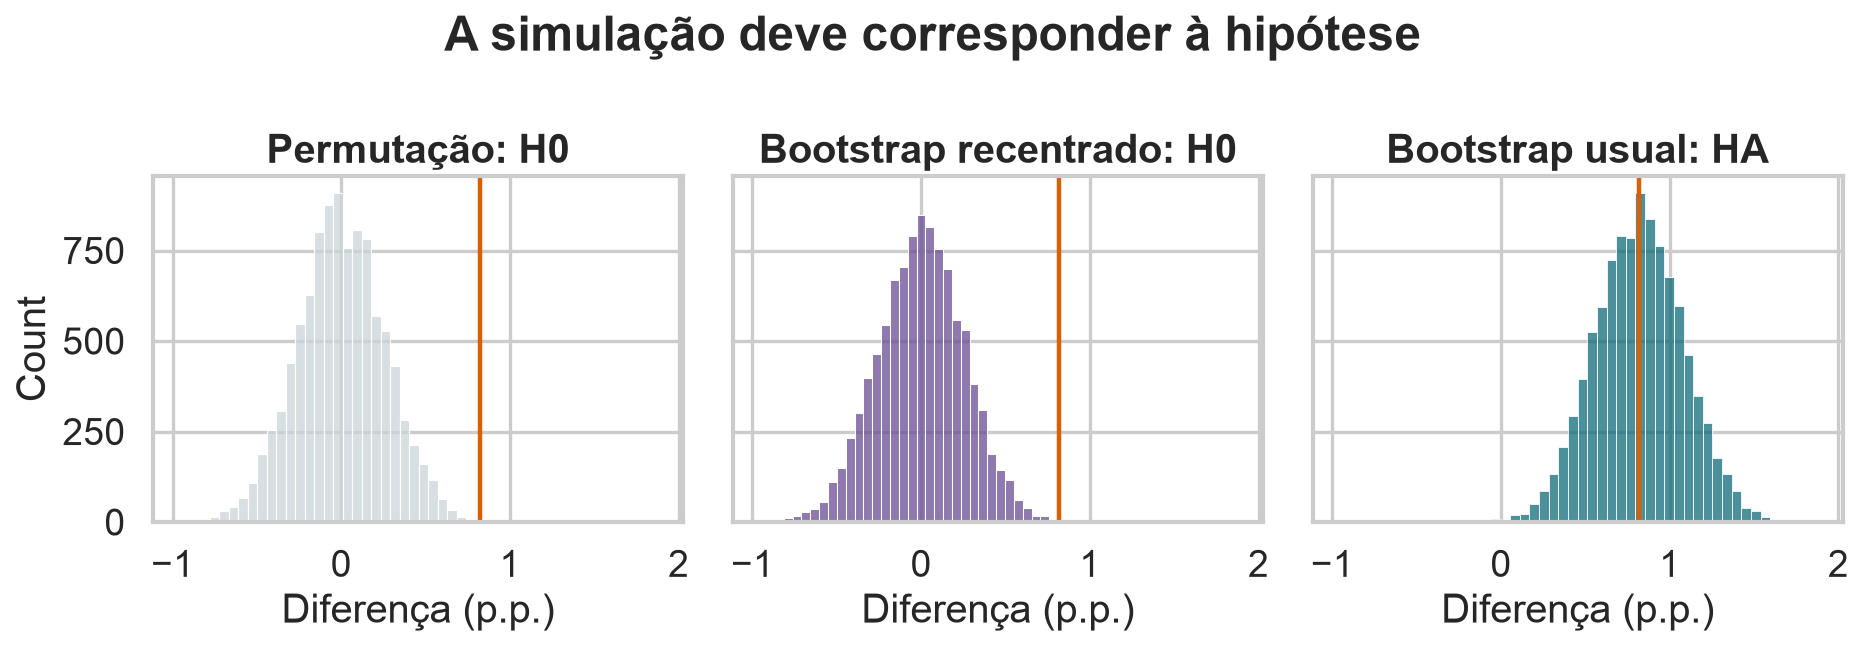

> **Interpretação**
>
> Permutação e bootstrap recentralizado respondem como a estatística
> varia sob ausência de efeito. O bootstrap usual responde quais efeitos
> são plausíveis ao redor da estimativa; por isso é mais natural para
> construir $H_A$ e intervalos.

# 9. Poder sob uma alternativa específica

In [ ]:
def simulated_power(p0, effect, n_each, reps=5000, alpha=.05, seed=1414):
    local_rng = np.random.default_rng(seed+n_each)
    a = local_rng.binomial(n_each, p0+effect, size=reps)/n_each
    b = local_rng.binomial(n_each, p0, size=reps)/n_each
    se0 = np.sqrt(2*p0*(1-p0)/n_each)
    reject = np.abs(a-b) > norm.ppf(1-alpha/2)*se0
    return reject.mean()

effects = [.0025, .005, observed]
sizes = [500, 1000, 2500, 5000, 10000, 25000, 45000]
power_table = pd.DataFrame({
    f"efeito={100*e:.2f} p.p.": [simulated_power(y40.mean(), e, n) for n in sizes]
    for e in effects
}, index=sizes)
power_table

In [ ]:
power_table.plot(marker="o")
plt.axhline(.80, color="darkorange", linestyle="--")
plt.xscale("log")
plt.xlabel("Jogadores por grupo")
plt.ylabel("Poder")
plt.show()

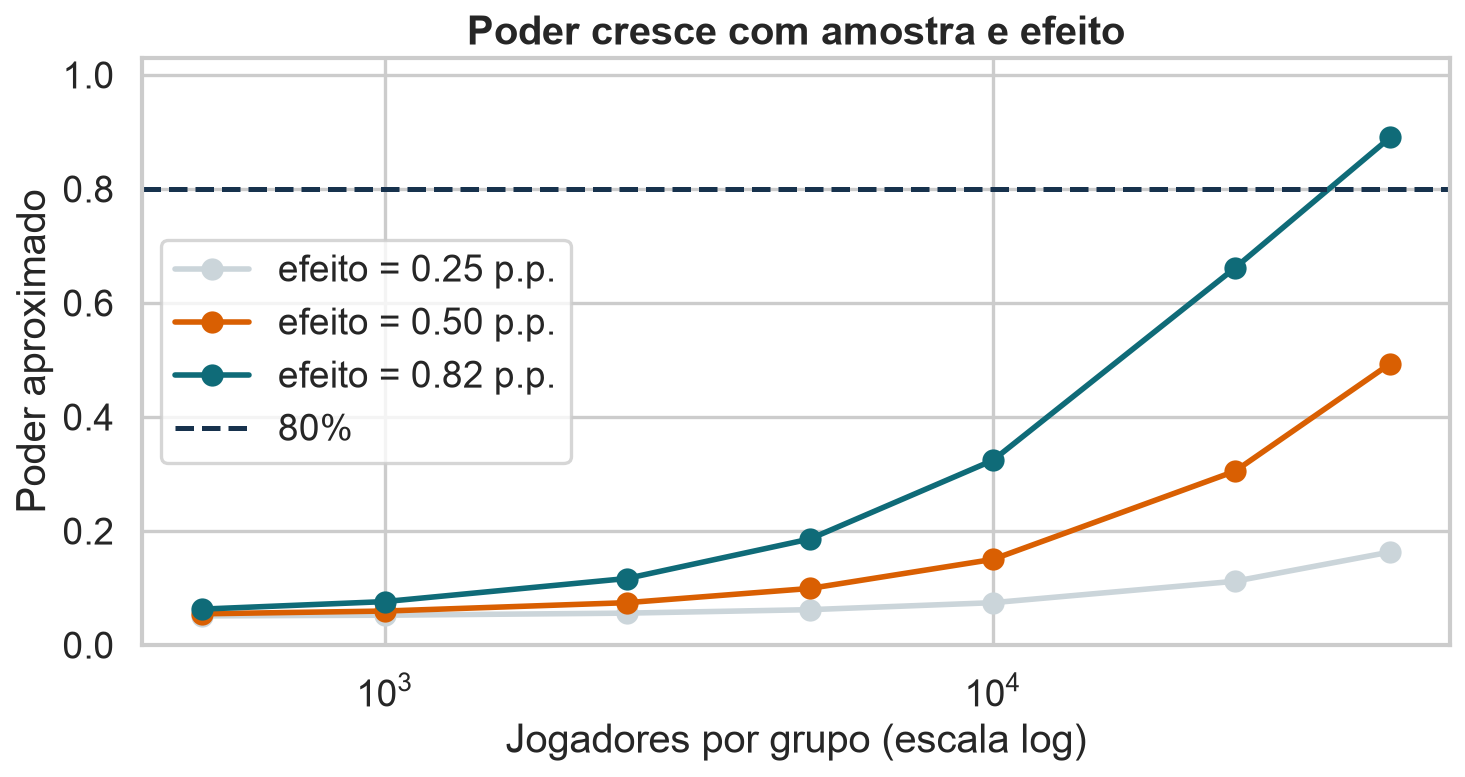

> **Interpretação**
>
> O poder aumenta tanto com $n$ quanto com o efeito verdadeiro. Efeitos
> pequenos exigem amostras muito maiores para alcançar 80%, portanto “o
> estudo tem poder” só faz sentido depois de especificar qual
> alternativa importa.

# 10. Muitos testes sob uma nula global

In [ ]:
m = 100
p_values_null = rng.uniform(size=m)
print("Valores-p abaixo de 0,05:", (p_values_null < .05).sum())
print("FWER teórica:", 1-(1-.05)**m)

> **Interpretação**
>
> Mesmo com todas as hipóteses nulas verdadeiras, cerca de 5 dos 100
> valores-p ficam abaixo de 0,05 em média, e a chance de ao menos um
> falso positivo é muito alta. É esse risco familiar que Bonferroni e
> Holm controlam; BH controla outra quantidade, a proporção falsa entre
> descobertas.

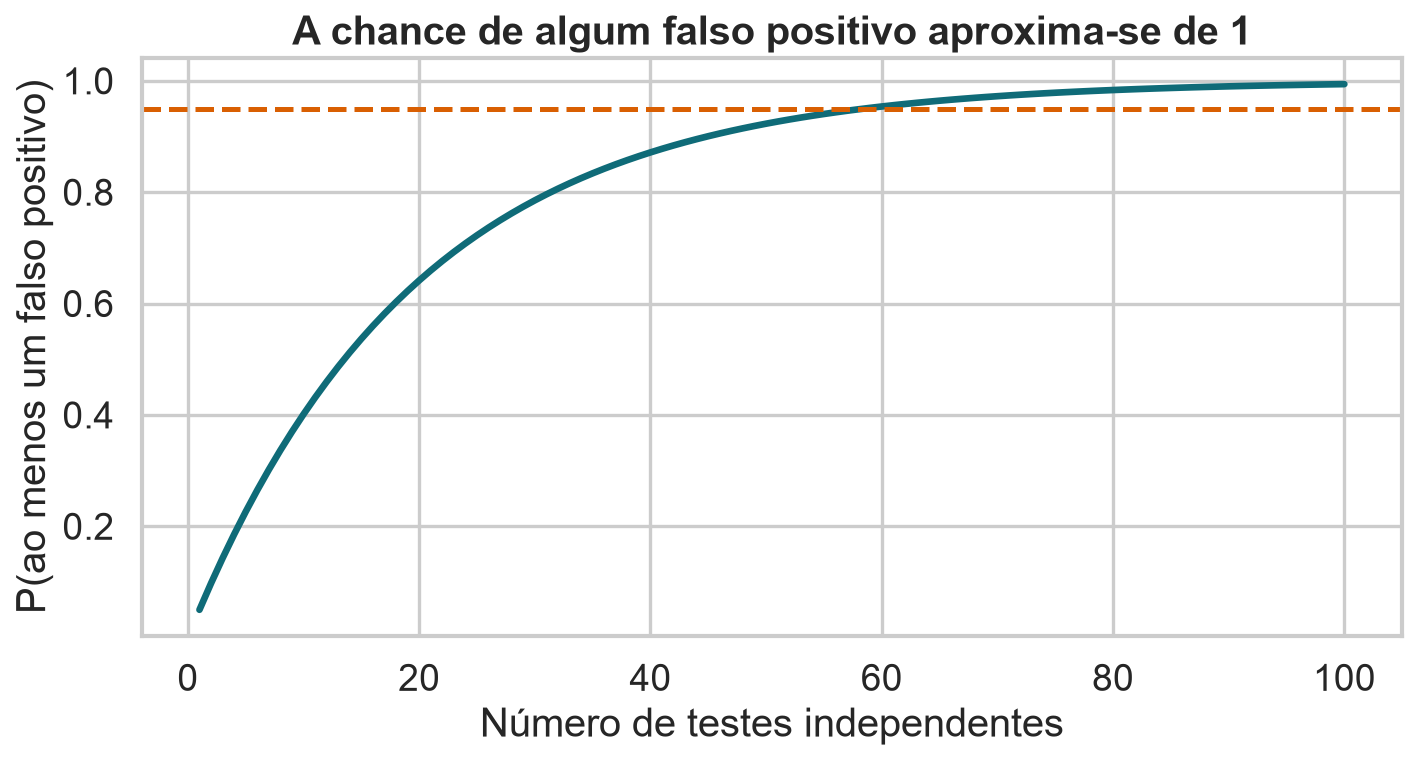

# 11. Bonferroni, Holm e BH

## 11.1 A família e a contabilidade dos erros

Considere uma família de $m$ hipóteses. Chamamos de $R$ o número de
hipóteses rejeitadas e de $V$ o número de rejeições falsas. As $R$
rejeições são as descobertas anunciadas; entre elas, $V$ correspondem a
hipóteses nulas que eram verdadeiras.

Não observamos $V$ diretamente. Por isso, os procedimentos de correção
não identificam qual descoberta é falsa: eles controlam o comportamento
de $V$ quando o estudo é repetido sob condições semelhantes.

### FWER: proteger a família contra qualquer falso positivo

$$
\operatorname{FWER}=P(V\geq1).
$$

Controlar FWER em 5% significa que, em repetições do procedimento
completo, a probabilidade de cometer **ao menos um** falso positivo na
família é no máximo 5%. É um critério apropriado quando uma única
afirmação falsa já teria custo elevado, como em uma decisão regulatória
ou na escolha confirmatória de uma métrica principal.

Com testes independentes, todos sob $H_0$ e executados individualmente
no nível $\alpha$:

$$
P(V\geq1)=1-(1-\alpha)^m.
$$

Essa igualdade descreve a inflação sem correção sob independência. A
definição de FWER não exige independência.

### FDR: controlar a fração falsa entre as descobertas

$$
\operatorname{FDR}=E\left[\frac{V}{\max(R,1)}\right].
$$

Controlar FDR em 5% significa controlar, em média, a proporção de
rejeições falsas entre as rejeições realizadas. Isso **não** quer dizer
que cada descoberta tenha 5% de probabilidade de ser falsa, nem que todo
estudo terá exatamente 5% de falsos positivos. FDR é natural em análises
exploratórias com muitas descobertas potenciais, nas quais aceitar
algumas falsas permite obter muito mais poder.

## 11.2 Bonferroni: dividir o orçamento de erro

Bonferroni testa cada hipótese no nível $\alpha/m$. A justificativa usa
a desigualdade da união:

$$
P\left(\bigcup_{i=1}^m A_i\right)
\leq \sum_{i=1}^mP(A_i)
\leq m\frac{\alpha}{m}=\alpha,
$$

em que $A_i$ é o evento de falso positivo no teste $i$. Portanto,
Bonferroni controla FWER mesmo quando os testes são dependentes. O
valor-p ajustado é

$$
p_i^{adj}=\min(mp_i,1).
$$

A simplicidade tem um custo: usar o mesmo limiar $\alpha/m$ para todos
os testes pode reduzir muito o poder.

## 11.3 Holm: controle sequencial de FWER

Holm ordena $p_{(1)}\leq\cdots\leq p_{(m)}$ e compara, em sequência,

$$
p_{(i)}\leq\frac{\alpha}{m-i+1}.
$$

Começamos com o mesmo limiar de Bonferroni. A cada rejeição, restam
menos hipóteses e o limiar fica menos severo. No primeiro fracasso, o
procedimento para e não rejeita as hipóteses restantes. Holm também
controla FWER sob dependência arbitrária e é uniformemente mais poderoso
que Bonferroni: nunca rejeita menos hipóteses para a mesma família.

## 11.4 BH: procedimento step-up para FDR

Benjamini–Hochberg (BH) ordena os valores-p, calcula $(i/m)q$ e procura
o **maior** índice $k$ que satisfaz

$$
p_{(k)}\leq\frac{k}{m}q.
$$

Em seguida rejeita as hipóteses de posições $1$ a $k$. BH não deve parar
no primeiro valor-p que falha. Sob independência e certas formas de
dependência positiva, ele controla FDR no nível $q$. Dependência
arbitrária pode exigir uma alternativa mais conservadora, como
Benjamini–Yekutieli.

## 11.5 Exemplo trabalhado

Considere $m=5$, $\alpha=q=0{,}05$ e os valores-p ordenados abaixo.

In [ ]:
p_values = np.array([.003, .011, .018, .041, .200])

comparacao = pd.DataFrame({"p": p_values})
for label, method in [
    ("Bonferroni", "bonferroni"),
    ("Holm", "holm"),
    ("BH", "fdr_bh"),
]:
    reject, adjusted, _, _ = multipletests(
        p_values, alpha=.05, method=method
    )
    comparacao[f"p ajustado — {label}"] = adjusted
    comparacao[f"rejeita — {label}"] = reject

comparacao.round(4)

Neste exemplo, Bonferroni rejeita apenas $p=0{,}003$; Holm rejeita
$0{,}003$ e $0{,}011$; BH rejeita também $0{,}018$. O aumento no número
de rejeições não significa que BH seja “melhor”: ele aceita uma meta de
erro diferente.

| método | quantidade controlada | interpretação | uso típico |
|------------------|------------------|------------------|------------------|
| Bonferroni | FWER | protege contra qualquer falso positivo | poucas decisões confirmatórias e alto custo de erro |
| Holm | FWER | mesma proteção, com limiares sequenciais | escolha padrão quando se quer controlar FWER |
| BH | FDR | controla a fração falsa esperada entre descobertas | muitas hipóteses exploratórias ou triagem |

Escolha o método com base no custo dos erros e no objetivo científico,
nunca apenas pelo número de resultados significativos que ele produz.

# 12. As três métricas de Cookie Cats

Construa uma família com retenção em 1 dia, retenção em 7 dias e uma
estatística robusta para rodadas. Aplique permutação a cada métrica e
ajuste os valores-p.

In [ ]:
metrics = ["retention_1", "retention_7"]
results = []
for metric in metrics:
    a = df.loc[df.version.eq("gate_30"), metric].astype(float).to_numpy()
    b = df.loc[df.version.eq("gate_40"), metric].astype(float).to_numpy()
    obs = a.mean()-b.mean()
    pooled_success = int(a.sum()+b.sum())
    sa = rng.hypergeometric(pooled_success, len(a)+len(b)-pooled_success,
                            len(a), size=50_000)
    null = sa/len(a)-(pooled_success-sa)/len(b)
    p = (1+np.sum(np.abs(null)>=abs(obs)))/(len(null)+1)
    results.append((metric, obs, p))

result = pd.DataFrame(results, columns=["métrica", "efeito", "p"])
result["p_bonferroni"] = multipletests(result.p, method="bonferroni")[1]
result["p_bh"] = multipletests(result.p, method="fdr_bh")[1]
result

# 13. Exercícios

1.  Compare os p-valores obtidos por permutação e bootstrap
    recentralizado.
2.  Calcule poder para efeitos de 0,25, 0,50 e 1,00 p.p.
3.  Encontre o tamanho amostral aproximado para 80% de poder em 0,50
    p.p.
4.  Simule famílias com 10, 50, 100 e 500 hipóteses nulas.
5.  Compare Bonferroni, Holm e BH quando há 5 efeitos reais entre 100
    testes.
6.  Mostre por simulação o *winner’s curse* ao reter apenas testes
    significativos.
7.  Discuta qual métrica deveria ser primária e quais seriam métricas de
    proteção.

# Fonte e limitações

Base Cookie Cats, versão `matinmahmoudi/rounds-and-retention` no Kaggle,
licença Apache 2.0. O conjunto é uma republicação educacional e não traz
todos os detalhes operacionais do experimento original. As conclusões
devem ser tratadas como um estudo de caso didático, não como
recomendação atual para o produto.

# Guia teórico consolidado

## Três distribuições diferentes

A distribuição observada descreve os dados. Uma distribuição sob $H_0$
representa resultados possíveis sem efeito; permutação costuma ser
natural quando o desenho torna os rótulos trocáveis. A distribuição sob
$H_A$ representa efeitos plausíveis; bootstrap é frequentemente natural
para aproximá-la a partir dos grupos observados.

Bootstrap também pode construir $H_0$: recentralizamos os grupos para
remover o efeito observado e reamostramos dentro das distribuições
recentralizadas. Isso é válido somente quando a transformação representa
adequadamente a hipótese nula.

## Poder é relativo a uma alternativa

Poder não é uma propriedade isolada do teste. Ele depende de tamanho do
efeito, variabilidade, amostra, regra de decisão e $\alpha$. Uma
simulação de poder deve especificar o mundo alternativo e repetir todo o
procedimento de análise. Aumentar $n$, reduzir ruído ou escolher uma
métrica mais informativa pode aumentar poder.

## Múltiplos testes

Com $m$ testes independentes no nível $\alpha$, todos sob a hipótese
nula, a probabilidade de ao menos um falso positivo é

$$\operatorname{FWER}=1-(1-\alpha)^m.$$

Em geral, $\operatorname{FWER}=P(V\geq1)$. Bonferroni testa cada
hipótese em $\alpha/m$ e controla FWER pela desigualdade da união. Holm
também controla FWER, mas ordena os valores-p e relaxa progressivamente
o limiar; por isso, nunca tem menos poder que Bonferroni.

Já $\operatorname{FDR}=E[V/\max(R,1)]$ controla a proporção falsa
esperada entre as descobertas. Benjamini–Hochberg ordena os valores-p,
encontra o maior $k$ com $p_{(k)}\leq(k/m)q$ e rejeita as primeiras $k$
hipóteses. FWER e FDR não são versões mais forte e mais fraca da mesma
resposta: representam compromissos científicos diferentes.

Definir uma métrica primária reduz multiplicidade. Correções não
consertam viés, p-hacking, mudança da hipótese após os dados ou seleção
de “vencedores”, que também tende a exagerar os efeitos observados.

# Questões de revisão da Aula 15

1.  Quando o bootstrap usual representa naturalmente $H_A$ e como ele
    pode ser adaptado para representar $H_0$?
2.  Quais quantidades são controladas por Bonferroni, Holm e
    Benjamini–Hochberg?

Respostas comentadas

1.  Ao reamostrar separadamente os grupos, preservamos o efeito
    observado e representamos alternativas plausíveis. Para $H_0$, é
    necessário remover a diferença, por exemplo recentralizando os
    dados.
2.  Bonferroni e Holm controlam FWER; Holm usa um procedimento
    sequencial. Benjamini–Hochberg controla FDR sob suas condições.